In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def to_wsl_path(win_path):
    # 1. Swap the slashes
    path = win_path.replace("\\", "/")
    
    # 2. Convert drive letter (e.g., "C:" to "/mnt/c")
    if ":" in path:
        drive, rest = path.split(":", 1)
        path = f"/mnt/{drive.lower()}{rest}"
        
    return path

In [3]:
path = "D:\Parth\code_work\customer_churn_dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv"

In [4]:
final_path = to_wsl_path(path)

In [5]:
df = pd.read_csv(final_path)

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:

for i in range(len(df.columns)):
    a = df.columns[i]
    print(f"{a} : {df[a].unique()} : {df[a].nunique()}")

customerID : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK'] : 7043
gender : ['Female' 'Male'] : 2
SeniorCitizen : [0 1] : 2
Partner : ['Yes' 'No'] : 2
Dependents : ['No' 'Yes'] : 2
tenure : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39] : 73
PhoneService : ['No' 'Yes'] : 2
MultipleLines : ['No phone service' 'No' 'Yes'] : 3
InternetService : ['DSL' 'Fiber optic' 'No'] : 3
OnlineSecurity : ['No' 'Yes' 'No internet service'] : 3
OnlineBackup : ['Yes' 'No' 'No internet service'] : 3
DeviceProtection : ['No' 'Yes' 'No internet service'] : 3
TechSupport : ['No' 'Yes' 'No internet service'] : 3
StreamingTV : ['No' 'Yes' 'No internet service'] : 3
StreamingMovies : ['No' 'Yes' 'No internet service'] : 3
Contract : ['Month-to-month' 'One year' 'Two year'] : 3
PaperlessBilling : ['Ye

In [8]:
df.shape

(7043, 21)

In [9]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# df.isnull().sum()

In [12]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.iloc[:,-1].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [15]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [16]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [18]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [19]:
df["TotalCharges"].dtype

dtype('O')

In [20]:
df["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

In [21]:
df[df["TotalCharges"].astype(str).str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [22]:
df["customerID"].duplicated().sum()

np.int64(0)

In [23]:
blank_total = df[df["TotalCharges"].astype(str).str.strip() == ""]

blank_total

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [24]:
blank_total['tenure'].value_counts()

tenure
0    11
Name: count, dtype: int64

In [25]:
blank_total['Churn'].value_counts()

Churn
No    11
Name: count, dtype: int64

In [26]:
len(blank_total)

11

In [27]:
blank_total[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "Churn"
    ]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


In [28]:
df[df["tenure"] == 0].shape

(11, 21)

In [29]:
df[df["tenure"] == 0][
    ["tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]
]

,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,0,52.55,,Two year,No
753,0,20.25,,Two year,No
936,0,80.85,,Two year,No
1082,0,25.75,,Two year,No
1340,0,56.05,,Two year,No
3331,0,19.85,,Two year,No
3826,0,25.35,,Two year,No
4380,0,20.00,,Two year,No
5218,0,19.70,,One year,No
6670,0,73.35,,Two year,No


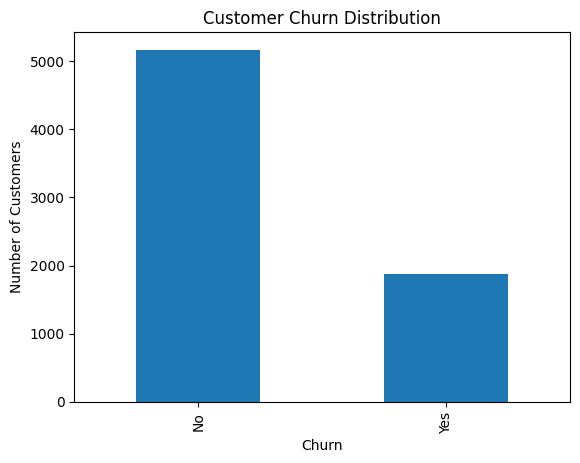

In [30]:

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [31]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


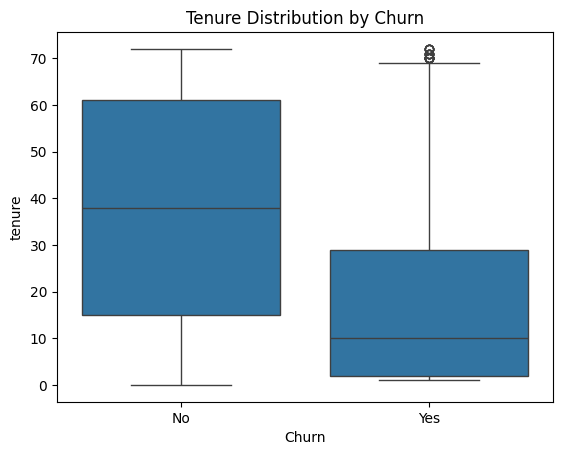

In [32]:
sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Tenure Distribution by Churn")
plt.show()

In [33]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-72"]
)

df.groupby("tenure_group", observed=True)["Churn"].value_counts(normalize=True)

tenure_group  Churn
0-6           Yes      0.529372
              No       0.470628
7-12          No       0.641135
              Yes      0.358865
13-24         No       0.712891
              Yes      0.287109
25-48         No       0.796110
              Yes      0.203890
49-72         No       0.904868
              Yes      0.095132
Name: proportion, dtype: float64

In [34]:
df.groupby("Contract")["Churn"].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

In [35]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [36]:
pd.crosstab(
    df["Contract"],
    df["tenure_group"],
    normalize="index"
)

tenure_group,0-6,7-12,13-24,25-48,49-72
Contract,,,,,
Month-to-month,0.364645,0.149935,0.190194,0.206968,0.088258
One year,0.026477,0.057705,0.133741,0.351663,0.430414
Two year,0.017109,0.023009,0.053097,0.161652,0.745133


In [37]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


In [38]:
df.groupby("InternetService")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
InternetService,,,,,,,,
DSL,2421.0,58.102169,16.259522,23.45,46.20,56.150,69.90,94.80
Fiber optic,3096.0,91.500129,12.663039,67.75,80.55,91.675,101.15,118.75
No,1526.0,21.079194,2.164221,18.25,19.70,20.150,20.90,26.90


In [39]:
pd.crosstab(
    df["InternetService"],
    df["Contract"],
    normalize="index"
)

Contract,Month-to-month,One year,Two year
InternetService,,,
DSL,0.505163,0.235440,0.259397
Fiber optic,0.687339,0.174096,0.138566
No,0.343381,0.238532,0.418087


In [40]:
pd.crosstab(
    [df["InternetService"], df["Contract"]],
    df["Churn"],
    normalize="index"
)

Churn                                 No       Yes
InternetService Contract                          
DSL             Month-to-month  0.677841  0.322159
                One year        0.907018  0.092982
                Two year        0.980892  0.019108
Fiber optic     Month-to-month  0.453947  0.546053
                One year        0.807050  0.192950
                Two year        0.927739  0.072261
No              Month-to-month  0.811069  0.188931
                One year        0.975275  0.024725
                Two year        0.992163  0.007837

In [41]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [42]:
df["charge_group"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 30, 60, 90, 120],
    labels=["0-30", "31-60", "61-90", "91-120"]
)

In [43]:
   pd.crosstab(
    df["charge_group"],
    df["Churn"],
    normalize="index"
) 

Churn,No,Yes
charge_group,,
0-30,0.901996,0.098004
31-60,0.740711,0.259289
61-90,0.660939,0.339061
91-120,0.672225,0.327775


In [44]:
df["charge_group"].value_counts().sort_index()

charge_group
0-30      1653
31-60     1265
61-90     2386
91-120    1739
Name: count, dtype: int64

In [45]:
pd.crosstab(
    df["charge_group"],
    df["Churn"]
)

Churn,No,Yes
charge_group,,
0-30,1491,162
31-60,937,328
61-90,1577,809
91-120,1169,570


In [46]:
corr_df = df[[
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges"
]].copy()

corr_df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

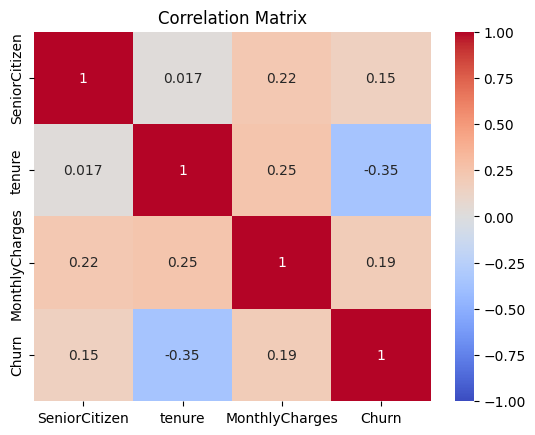

In [47]:
corr = corr_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")
plt.show()

In [48]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [49]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [50]:
df.loc[df["TotalCharges"].isna(), "TotalCharges"] = 0

In [51]:
df["TotalCharges"].dtype

dtype('float64')

In [52]:
df["TotalCharges"].isna().sum()

np.int64(0)

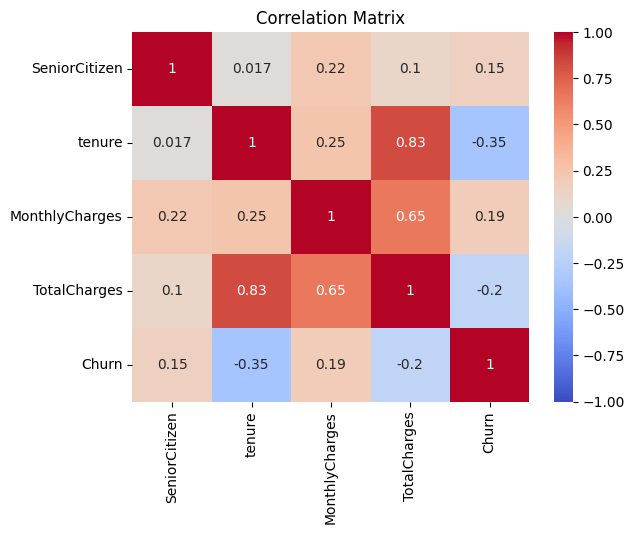

In [53]:
corr_df = df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
].copy()

corr_df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

corr = corr_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")
plt.show()

In [54]:
categorical_features = df.select_dtypes(include="object").columns.drop(
    ["customerID", "Churn"]
)

categorical_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [55]:
for col in categorical_features:
    print(f"\n{'='*50}")
    print(col)
    print(pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    ))


gender
Churn         No       Yes
gender                    
Female  0.730791  0.269209
Male    0.738397  0.261603

Partner
Churn          No       Yes
Partner                    
No       0.670420  0.329580
Yes      0.803351  0.196649

Dependents
Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.845498  0.154502

PhoneService
Churn               No       Yes
PhoneService                    
No            0.750733  0.249267
Yes           0.732904  0.267096

MultipleLines
Churn                   No       Yes
MultipleLines                       
No                0.749558  0.250442
No phone service  0.750733  0.249267
Yes               0.713901  0.286099

InternetService
Churn                  No       Yes
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050

OnlineSecurity
Churn                      No       Yes
OnlineSecurity              

In [56]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [57]:
pd.crosstab(
    df["PaymentMethod"],
    df["Contract"],
    normalize="index"
)

Contract,Month-to-month,One year,Two year
PaymentMethod,,,
Bank transfer (automatic),0.381477,0.253238,0.365285
Credit card (automatic),0.356767,0.261498,0.381735
Electronic check,0.782241,0.146723,0.071036
Mailed check,0.553970,0.209057,0.236973


In [58]:
pd.crosstab(
    [df["PaymentMethod"], df["Contract"]],
    df["Churn"],
    normalize="index"
)

Churn                                           No       Yes
PaymentMethod             Contract                          
Bank transfer (automatic) Month-to-month  0.658744  0.341256
                          One year        0.902813  0.097187
                          Two year        0.966312  0.033688
Credit card (automatic)   Month-to-month  0.672192  0.327808
                          One year        0.896985  0.103015
                          Two year        0.977625  0.022375
Electronic check          Month-to-month  0.462703  0.537297
                          One year        0.815562  0.184438
                          Two year        0.922619  0.077381
Mailed check              Month-to-month  0.684211  0.315789
                          One year        0.931751  0.068249
                          Two year        0.992147  0.007853

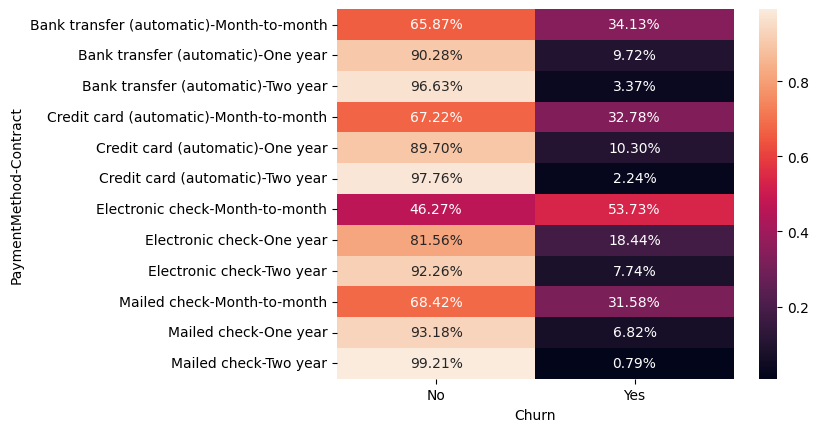

In [59]:
ct = pd.crosstab(
    [df["PaymentMethod"], df["Contract"]],
    df["Churn"],
    normalize="index"
)

sns.heatmap(ct, annot=True, fmt=".2%")
plt.show()

In [60]:
df.groupby("PaymentMethod")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
PaymentMethod,,,,,,,,
Bank transfer (automatic),1544.0,43.656736,23.197901,0.0,23.0,48.0,66.0,72.0
Credit card (automatic),1522.0,43.269382,23.339581,0.0,23.0,47.0,66.0,72.0
Electronic check,2365.0,25.174630,22.382301,1.0,5.0,18.0,43.0,72.0
Mailed check,1612.0,21.830025,21.218374,0.0,3.0,15.0,36.0,72.0


In [61]:
df.groupby("PaymentMethod")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
PaymentMethod,,,,,,,,
Bank transfer (automatic),1544.0,67.192649,30.555200,18.40,41.0875,73.100,92.9625,118.75
Credit card (automatic),1522.0,66.512385,30.612424,18.25,38.6625,73.025,90.8500,117.50
Electronic check,2365.0,76.255814,24.053655,18.85,60.1500,80.550,94.7000,118.65
Mailed check,1612.0,43.917060,26.314665,18.70,20.1500,34.700,64.9125,118.60


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   object  
 4   Dependents        7043 non-null   object  
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   object  
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

In [63]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
tenure_group        0
charge_group        0
dtype: int64

In [64]:
df_model = df.drop(columns=["tenure_group", "charge_group"])

In [65]:
df_model = df_model.drop(columns=["customerID"])

In [66]:
df_model.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [67]:
df_model.iloc[:,-1]

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: object

In [68]:
y = df_model.iloc[:,-1]

In [69]:
x = df_model.iloc[:,:-1]


In [70]:
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [71]:
y

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: object

In [72]:
from sklearn.model_selection import train_test_split


In [73]:

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [74]:
print(x_test.shape)
print(x_train.shape)

print(y_test.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))


(1409, 19)
(5634, 19)
Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64
Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64


In [75]:
numerical_features = x_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = x_train.select_dtypes(
    include=["object", "category"]
).columns

In [76]:
print("Numerical:", list(numerical_features))
print("Categorical:", list(categorical_features))

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [77]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [78]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [79]:
preprocessor.fit(x_train)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [80]:
X_train_processed = preprocessor.transform(x_train)
X_test_processed = preprocessor.transform(x_test)

In [81]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 45)
(1409, 45)


In [82]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names)

45
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service'
 'cat__OnlineSecurity_Yes' 'cat__OnlineBackup_No'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No' 'cat__DeviceProtection_No internet service'
 'cat__DeviceProtection_Yes' 'cat__TechSupport_No'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes'
 'cat__StreamingTV_No' 'cat__StreamingTV_No internet service'
 'cat__StreamingTV_Yes' 'cat__StreamingMovies_No'
 'cat__StreamingMovies_No internet service' 'cat__StreamingMovies_Yes'
 'cat__Contract_Mon

In [83]:
print(type(x_train))
print(type(X_train_processed))
print(X_train_processed.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>
(5634, 45)


In [84]:
y_train_encoded = y_train.map({
    "No": 0,
    "Yes": 1
})

y_test_encoded = y_test.map({
    "No": 0,
    "Yes": 1
})

In [85]:
print(y_train_encoded.value_counts())
print(y_test_encoded.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64
Churn
0    1035
1     374
Name: count, dtype: int64


In [86]:
from sklearn.linear_model import LogisticRegression


In [87]:

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


In [88]:

model.fit(
    X_train_processed,
    y_train_encoded
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [89]:
y_pred = model.predict(X_test_processed)

In [90]:
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [91]:
y_prob = model.predict_proba(X_test_processed)[:, 1]

In [92]:
y_prob

array([0.04591993, 0.68371345, 0.05893985, ..., 0.15442215, 0.00428645,
       0.00628801], shape=(1409,))

In [93]:
from sklearn.metrics import confusion_matrix


In [94]:

cm = confusion_matrix(
    y_test_encoded,
    y_pred,
    labels =[0,1]
)

print(cm)

[[926 109]
 [165 209]]


In [95]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred)
recall = recall_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8055358410220014
Precision: 0.6572327044025157
Recall   : 0.5588235294117647
F1 Score : 0.6040462427745664


In [96]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    y_pred
))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [97]:
from sklearn.metrics import roc_auc_score


In [98]:

roc_auc = roc_auc_score(
    y_test_encoded,
    y_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8421349040274871


In [99]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    y_test_encoded,
    y_prob
)

print("PR-AUC:", pr_auc)

PR-AUC: 0.6343385058492537


In [100]:
thresholds = [0.50, 0.40, 0.30, 0.20]

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_encoded,
        y_pred_threshold
    ).ravel()

    precision = precision_score(
        y_test_encoded,
        y_pred_threshold
    )

    recall = recall_score(
        y_test_encoded,
        y_pred_threshold
    )

    f1 = f1_score(
        y_test_encoded,
        y_pred_threshold
    )

    print(f"\nThreshold: {threshold}")
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1:        {f1:.3f}")


Threshold: 0.5
TN: 926, FP: 109, FN: 165, TP: 209
Precision: 0.657
Recall:    0.559
F1:        0.604

Threshold: 0.4
TN: 845, FP: 190, FN: 124, TP: 250
Precision: 0.568
Recall:    0.668
F1:        0.614

Threshold: 0.3
TN: 774, FP: 261, FN: 92, TP: 282
Precision: 0.519
Recall:    0.754
F1:        0.615

Threshold: 0.2
TN: 670, FP: 365, FN: 54, TP: 320
Precision: 0.467
Recall:    0.856
F1:        0.604


In [101]:
coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

feature_importance["abs_coefficient"] = (
    feature_importance["coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "abs_coefficient",
    ascending=False
)

print(feature_importance.head(15))

                                      feature  coefficient  abs_coefficient
1                                 num__tenure    -1.257539         1.257539
38                     cat__Contract_Two year    -0.776594         0.776594
15                   cat__InternetService_DSL    -0.648646         0.648646
16           cat__InternetService_Fiber optic     0.634195         0.634195
2                         num__MonthlyCharges    -0.591863         0.591863
36               cat__Contract_Month-to-month     0.582883         0.582883
3                           num__TotalCharges     0.536253         0.536253
39                   cat__PaperlessBilling_No    -0.343227         0.343227
25  cat__DeviceProtection_No internet service    -0.300104         0.300104
17                    cat__InternetService_No    -0.300104         0.300104
19    cat__OnlineSecurity_No internet service    -0.300104         0.300104
28       cat__TechSupport_No internet service    -0.300104         0.300104
31       cat

In [102]:
from sklearn.ensemble import RandomForestClassifier

In [103]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(
    X_train_processed,
    y_train_encoded
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [104]:
rf_pred = rf_model.predict(X_test_processed)
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

In [105]:


print(classification_report(y_test_encoded, rf_pred))

print("ROC-AUC:",
      roc_auc_score(y_test_encoded, rf_prob))

print("PR-AUC:",
      average_precision_score(y_test_encoded, rf_prob))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409

ROC-AUC: 0.8226898137384071
PR-AUC: 0.6131028312864323


In [106]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

search = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=15,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_processed, y_train_encoded)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,15
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [107]:
print("Best parameters:")
print(search.best_params_)

print("Best CV ROC-AUC:")
print(search.best_score_)

Best parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}
Best CV ROC-AUC:
0.8467633086636569


In [108]:
best_rf = search.best_estimator_

rf_tuned_pred = best_rf.predict(X_test_processed)
rf_tuned_prob = best_rf.predict_proba(X_test_processed)[:, 1]

print(classification_report(
    y_test_encoded,
    rf_tuned_pred
))

print("Test ROC-AUC:",
      roc_auc_score(y_test_encoded, rf_tuned_prob))

print("Test PR-AUC:",
      average_precision_score(y_test_encoded, rf_tuned_prob))

              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1035
           1       0.54      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

Test ROC-AUC: 0.8410783022036219
Test PR-AUC: 0.6474930902981488


In [109]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(best_rf, "churn_model.pkl")

['churn_model.pkl']

In [110]:
loaded_preprocessor = joblib.load("preprocessor.pkl")
loaded_model = joblib.load("churn_model.pkl")

print(type(loaded_preprocessor))
print(type(loaded_model))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [112]:
X_test_loaded = loaded_preprocessor.transform(x_test)

loaded_predictions = loaded_model.predict(X_test_loaded)

print(loaded_predictions[:20])

[0 1 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0]


In [113]:
print(np.array_equal(
    loaded_predictions,
    rf_tuned_pred
))

True


In [114]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_rf)
])

In [115]:
final_pipeline.fit(
    x_train,
    y_train_encoded
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [117]:
final_pipeline.predict(x_test)

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [118]:
joblib.dump(
    final_pipeline,
    "/mnt/d/Parth/code_work/churn_pipeline.pkl"
)

['/mnt/d/Parth/code_work/churn_pipeline.pkl']

In [119]:
loaded_pipeline = joblib.load("/mnt/d/Parth/code_work/churn_pipeline.pkl")

predictions = loaded_pipeline.predict(x_test)

print(predictions[:20])

[0 1 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0]
